Data Exploration Challenge

For today's data exploration challenge, I will just be exploring the hrv_measurements.csv data file provided by the Welltory COVID-19 and Wearables Open Data Research dataset. After all, all of the participants studied in this dataset are assigned tags indicating COVID-19 status, which provides an easy way to correlate individuals that have COVID-19 with other statistics such as bpm, amo, etc.

I) Understand your data - what do the features mean? (May have to do some info gathering)

This particular dataset consists of the following features:
1) user_code: Unique user ID
2) rr_code: Unique measurement ID
3) measurement_datetime: Measurement datetime in YYYY-MM-DD hh:mm:ss format
4) time_of_day: Time of day: 'evening', 'morning', 'night' or 'day'
5) bpm: Heart rate during measurement (in beats per minute)
6) meanrr: Average time between each heartbeat (in milliseconds)
7) mxdmn: The difference between highest and lowest cardio interval values (in seconds)
8) sdnn: Standard deviation of normal heartbeat intervals (in milliseconds)
9) rmssd: Root mean square of successive differences for consecutive intervals (in milliseconds)
10) pnn50: Percent of RR-intervals that fall outside a 50 ms range of the average (in %)
11) mode: The most common cardio interval length in a measurement (in milliseconds)
12) amo: Mode amplitude
13) lf: the power of low frequency waves (in milliseconds)
14) hf:  the power of high frequency waves (in milliseconds)
15) vlf: power of very low frequency waves (in milliseconds)
16) lfhf: ratio of low to high frequency waves
17) total_power: the total power of HF, LF, and VLF waves generated by the heart (in milliseconds)
18) how_feel: Health score — answers to "How do you feel physically?" in the post-measurement survey.
19) how_mood: Mood score — answers to "How is your mood?" in the post-measurement survey.
20) how_sleep: Sleep score —answers to "How did you sleep?" in the post-measurement survey.
21) rr_data: Intervals in milliseconds between consecutive heart beats as a comma-separated string
22) tags: Tags assigned by user as a comma-separated string (including about the specific context in which the individual was studied (ex. Has COVID-19, on diet, morning, etc.))

II) Document data context and data sampling in markdown

The data in the hrv_measurements.csv file is sampled from data based on heart rate variability (HRV) measurements collected from COVID-19 participants via the Welltory app.

III) Explore and interpret data structure, descriptive
statistics, data quality, and variable relationships

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('hrv_measurements.csv')

# Explore Data Structure (The following code is based on https://github.com/AIPI510/aipi510-fall25/blob/main/starters/exploratory_data_analysis.ipynb)
print(f"Dimensions: {df.shape}")
print(f"Data Types:\n{df.dtypes}")
print(f"Missing Values:\n{df.isnull().sum()}")

Dimensions: (3245, 22)
Data Types:
user_code                object
rr_code                  object
measurement_datetime     object
time_of_day              object
bpm                       int64
meanrr                  float64
mxdmn                   float64
sdnn                    float64
rmssd                   float64
pnn50                   float64
mode                    float64
amo                     float64
lf                      float64
hf                      float64
vlf                     float64
lfhf                    float64
total_power             float64
how_feel                  int64
how_mood                  int64
how_sleep               float64
tags                     object
rr_data                  object
dtype: object
Missing Values:
user_code                  0
rr_code                    0
measurement_datetime       0
time_of_day                0
bpm                        0
meanrr                     0
mxdmn                      0
sdnn                       0

Interpretation of data structure

This indicates that there are 3245 observations of individuals that have been recorded (not necessarily 3245 individuals since some appear more than once) with each having 21 feature measurements and 1 target measurement (that being tags which may or may not indicate COVID-19 status).

Please see "I) Understand your data - what do the features mean? (May have to do some info gathering)" for the definitions of the above data types.

Unfortunately, the how_sleep and tags columns are not filled for a ot of the observations that have been recorded, meaning that deletions of rows is going to be necessary (not imputation though because there are several tags that are missing to the point where imputation may misrepresent the underlying trends in the data).

In [10]:
# Descriptive Statistics (The following code is based on https://github.com/AIPI510/aipi510-fall25/blob/main/starters/exploratory_data_analysis.ipynb)
print("\nDescriptive Statistics")
numeric_columns = df.select_dtypes(include=[np.number]).columns
print("Central Tendency Measures:")
print(df[numeric_columns].describe().loc[['mean', '50%']])
print("\nDispersion Measures:")
print(df[numeric_columns].describe().loc[['std', 'min', 'max']])

print("\n------------------------\n")

# Check for distribution normality (skewness and kurtosis)
print("\nDistribution Measures:")
print(df[numeric_columns].skew())
print(df[numeric_columns].kurt())


Descriptive Statistics
Central Tendency Measures:
            bpm      meanrr     mxdmn       sdnn      rmssd      pnn50  \
mean  73.257935  839.600366  0.184635  52.489218  52.814196  20.615609   
50%   72.000000  829.100000  0.160000  46.919000  42.869000  16.160000   

          mode       amo          lf           hf         vlf      lfhf  \
mean  0.837465  46.78829  927.038213  1125.041294  578.229892  2.397769   
50%   0.825000  45.00000  423.000000   380.000000  293.000000  0.862000   

      total_power  how_feel  how_mood  how_sleep  
mean  2630.309399 -0.235439 -0.076733  -0.065484  
50%   1387.000000  0.000000  0.000000   0.000000  

Dispersion Measures:
            bpm       meanrr     mxdmn        sdnn       rmssd      pnn50  \
std   12.201088   137.420367  0.107456   29.369506   39.353213  18.588156   
min   44.000000   477.730000  0.030000    9.515000    6.340000   0.000000   
max  125.000000  1346.740000  0.790000  206.631000  310.800000  91.920000   

         mode   

In [11]:
# Data Quality (This code is based on https://github.com/AIPI510/aipi510-fall25/blob/main/starters/exploratory_data_analysis.ipynb)
print("\nData Quality")
print(f"Duplicated Rows: {df.duplicated().sum()}")
print("Checking for Inconsistent Values:")
print(df.apply(lambda x: x.value_counts().index[0]).to_frame('most_frequent_value'))


Data Quality
Duplicated Rows: 0
Checking for Inconsistent Values:
                                                    most_frequent_value
user_code                                                    a62c11c164
rr_code                                                      bc4c855cc7
measurement_datetime                                2020-05-15 09:31:35
time_of_day                                                     morning
bpm                                                                  66
meanrr                                                           791.43
mxdmn                                                              0.17
sdnn                                                             53.252
rmssd                                                            22.422
pnn50                                                               0.0
mode                                                              0.825
amo                                                                44


Variable Relationships

Correlation Matrix:
                  bpm    meanrr     mxdmn      sdnn     rmssd     pnn50  \
bpm          1.000000 -0.977724 -0.343935 -0.341514 -0.214339 -0.408006   
meanrr      -0.977724  1.000000  0.348015  0.348052  0.231696  0.445640   
mxdmn       -0.343935  0.348015  1.000000  0.954639  0.846259  0.777242   
sdnn        -0.341514  0.348052  0.954639  1.000000  0.909046  0.810236   
rmssd       -0.214339  0.231696  0.846259  0.909046  1.000000  0.843065   
pnn50       -0.408006  0.445640  0.777242  0.810236  0.843065  1.000000   
mode        -0.956984  0.979400  0.262628  0.258114  0.128843  0.361014   
amo          0.547373 -0.533668 -0.750213 -0.759049 -0.595028 -0.718982   
lf          -0.171505  0.176511  0.717783  0.743380  0.629966  0.558850   
hf          -0.105204  0.128630  0.740832  0.773958  0.857374  0.727759   
vlf         -0.240630  0.242066  0.491447  0.489891  0.274702  0.288167   
lfhf        -0.003373 -0.024851  0.027057 -0.022080 -0.

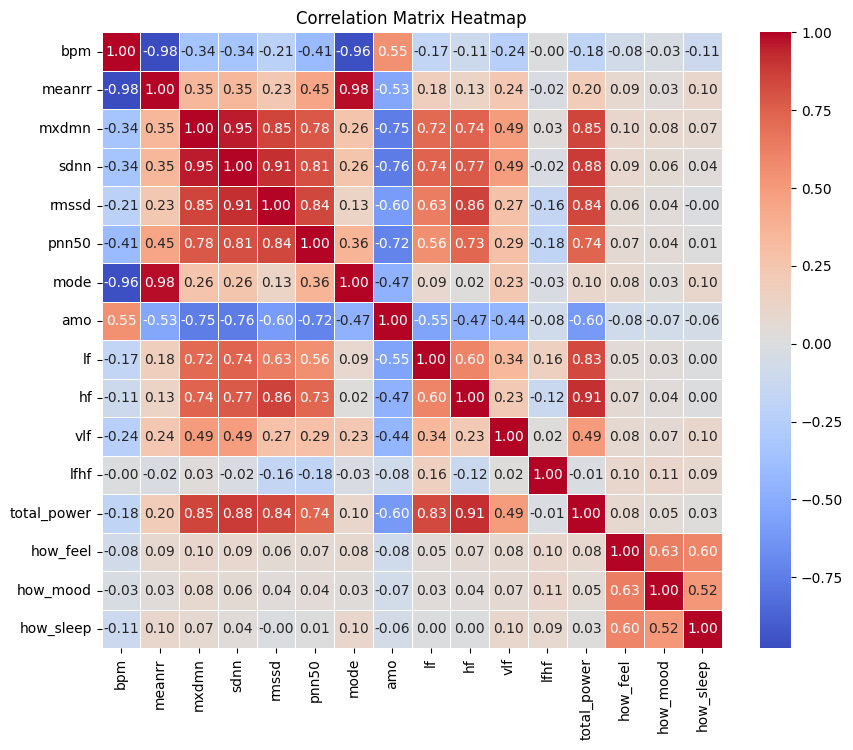

In [12]:
# This code is based on https://github.com/AIPI510/aipi510-fall25/blob/main/starters/exploratory_data_analysis.ipynb
# Variable Relationships
print("\nVariable Relationships")
print("\nCorrelation Matrix:")
correlation_matrix = df[numeric_columns].corr()
print(correlation_matrix)

# Visualize the Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

IV) Explore data visually with appropriate visualizations

Text(0.5, 1.0, 'bpm Measurements')

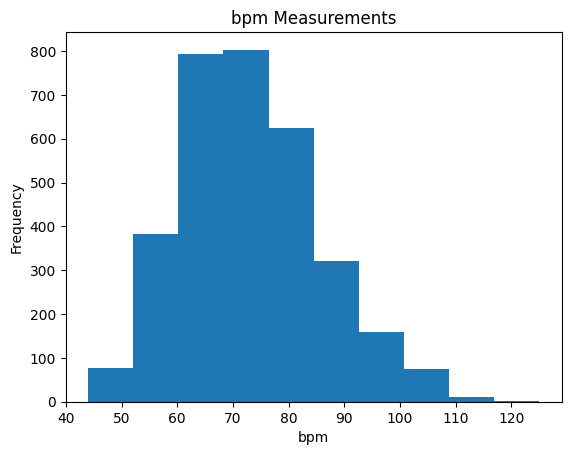

In [13]:
# This code is original to me
plt.hist(df['bpm'])
plt.xlabel("bpm")
plt.ylabel("Frequency")
plt.title("bpm Measurements")

Text(0.5, 1.0, 'meanrr Measurements')

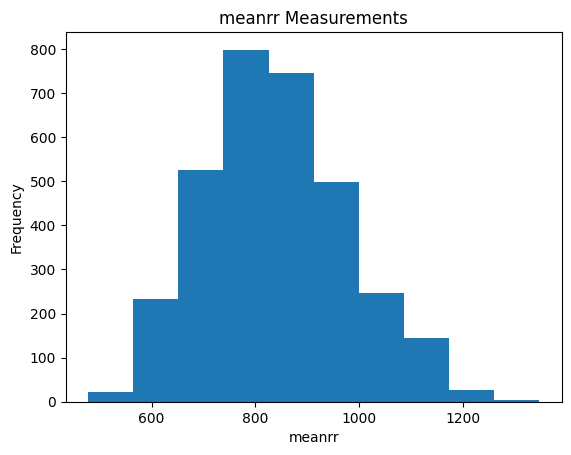

In [14]:

plt.hist(df['meanrr'])
plt.xlabel("meanrr")
plt.ylabel("Frequency")
plt.title("meanrr Measurements")

# Discussion On What I Have Completed, Intended To Complete, Next Steps

## What I Have Completed
I understood the features that were provided in the hrv_measurements.csv data file, explained the context of the data and and where it was sampled from, explored and interpreted the structure of the data, extrapolated descriptive statistics, analyzed data quality, analyzed variable relationships, and began to explore the data visually (specifically for bpm and frequency through the use of histograms)

## What Was Intended To Have Been Completed In Addition
Unfortunately, a lot of time was taken to understand and explore the 22 features that existed in the dataset. Therefore, the following additional items which were intended to be completed were not completed:
1) Finish visualizations of rest of features (for numerical features: histograms and for the tags: a pie chart representing frequencies of different kinds of responses such as COVID-19, hydrotherapy, etc.)
2) Implemented strategies for Handling Missing Values (simply deleting the rows of the dataframe) and Outliers but would not have worried about duplicates (since there aren't any)
3) Would have created additonal columns through one-hot encodings for COVID-19 status, hydrotherapy status, etc. based on the tags columns free responses
4) Would have created a COVID-19 status new feature at a minimum because that would provide the dataset a column of information corresponding to COVID-19 status for each of the in
5) Would have explained data quality assessment, including data profiling, data completeness, data accuracy, data consistency, data integrity, and data lineage and provenance (at a high level, the data is fairly good in quality as far as the filled-in values are concerned; however, there are a lot of missing values for the tags which I found to be disappointing from a data completeness standpoint. Also, the data seems to be accurate, consistent, and fair in terms of data integrity. The data lineage and provenance has already been discussed in section II).


V) Discuss and implement strategies for Handling Missing
Values, Removing Duplicates, and Handling Outliers

VI) Perform data transformation as appropriate

VII) Create at least one new feature and document your approach

VIII) Include a discussion around data quality assessment,
including data profiling, data completeness, data
accuracy, data consistency, data integrity, and data
lineage and provenance

● IMPORTANT: provide rationale for choices